# Description

In the second part of the project I did a preliminary statistical test with some fixed hyperparameters to understand which algorithms behave better.

There are two different sources oif sthocasticity:
1. **The noise used to generate synthetic observations, ruled by specific seed.**
2. **The inntrinsic sthocaticity of the algorithms used, ruled by specific seed different from the other.**

To test the statistical robusteness of the algorithms I varied the bothe the seed for the noise and the seed for the optimisation algorithm using the subsequent Workflow:




1. **For loop over $p$ for the noise seed**
    1. **For loop over $k$ to determine the clay content $C$**
        1. **Generate a true model using forward modelling and compute three true measurements**
            - $V_p$
            - $V_s$
            - $\sigma$
        2. **Generate three noisy measurements adding gaussian noise**
        3. **For loop over $s$ for the algorithm seed**
            1. **Run the inversion and obtain the parameter vector $\vec{v}$, containing  five parameters, which depends on $p$, $k$, and $s$:**
               $$
               \vec{v}(p,k,s)
               $$
            2. **Compute the errors for each parameter**
        4. **For fixed $p$ and $k$, for each parameter obtain two error vectors (signed errors and absolute errors) as $s$ varies**
        5. **For fixed $p$, for each parameter obtain two error matrices of dimension $k\times s$ (signed errors and absolute errors) as $k$ and $s$ varies**

2. **At the end, for each parameter we obtain two 3D tensors of errors as $k$ and $s$ varies**
   - $err[p,k,s]$
   - $aerr[p,k,s]$
3. **Use this tensors to compute some error-metrics**

It is important to say that to be able to say wether a certain algorithm behave better than an other, a grid search approach should be carried out to test also other hyperparameters.

Because lack of time I didn't use Numba to accelerate **CMA-ES** and so I couldn't finish the statistical analysis for **CMA-ES** because the code was too slow.

# SA


RUN p = 0, k = 0
TRUE:
  Vp_true    = 1332.04 m/s
  Vs_true    = 101.384 m/s
  sigma_true = 0.293161 S/m

OBS (1% noise):
  Vp_obs     = 1335.13 m/s
  Vs_obs     = 101.415 m/s
  sigma_obs  = 0.296745 S/m
246

  seed_inversion = 246
  Best objective f = 7.887024e-13
  phi_percent   = 42.154201
  C_percent     = 5.150371
  S_b_percent   = 96.341168
  sigma_b_inv   = 0.577055
  xi            = 2.571439

Absolute deviations:
  |devPHI| (pp) = 1.1542
  |devCC|  (pp) = 4.8496
  |devSB|  (pp) = 6.3412
  |devROb| (%)  = 15.4109
  |devfac| (%)  = 4.7615
247

  seed_inversion = 247
  Best objective f = 9.112711e-13
  phi_percent   = 42.864131
  C_percent     = 3.515723
  S_b_percent   = 84.265947
  sigma_b_inv   = 0.452144
  xi            = 2.502369

Absolute deviations:
  |devPHI| (pp) = 1.8641
  |devCC|  (pp) = 6.4843
  |devSB|  (pp) = 5.7341
  |devROb| (%)  = 9.5713
  |devfac| (%)  = 7.3197
248

  seed_inversion = 248
  Best objective f = 1.360968e+01
  phi_percent   = 40.458982
  C_percent 

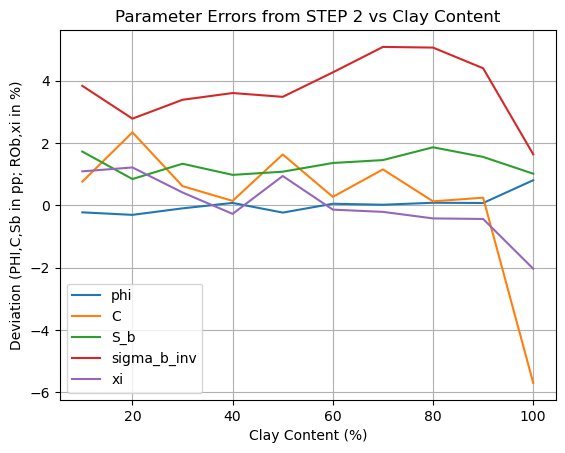

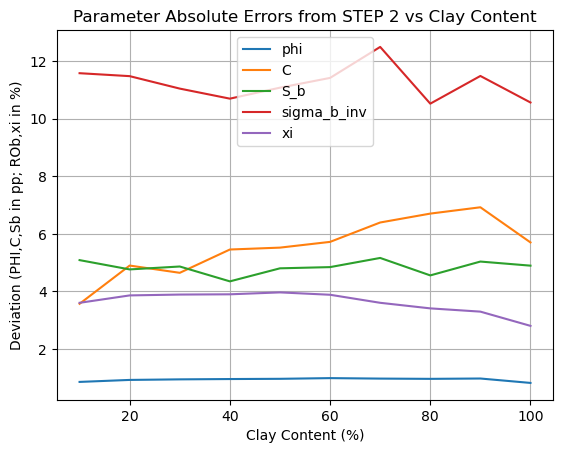

In [13]:
from dataclasses import dataclass
import numpy as np
import math
import matplotlib.pyplot as plt
from numba import njit


#############################################################
# 1) Fixed physical parameters
#############################################################

@dataclass
class RockFluidConstants:
    # Quartz phase
    K_q: float = 37.3e9
    mu_q: float = 44.3e9
    rho_q: float = 2600.0
    sigma_q: float = 1e-6

    # Clay phase (second solid phase)
    K_c: float = 20.9e9
    mu_c: float = 6.9e9
    rho_c: float = 2650.0
    sigma_c: float = 0.1

    # Brine phase
    K_b: float = 2.25e9
    rho_b: float = 1030.0

    # Air phase
    K_a: float = 76e3
    rho_a: float = 1.2
    sigma_a: float = 1e-4


def const_to_array(c: RockFluidConstants) -> np.ndarray:
    return np.array(
        [
            c.K_q, c.mu_q, c.rho_q, c.sigma_q,
            c.K_c, c.mu_c, c.rho_c, c.sigma_c,
            c.K_b, c.rho_b,
            c.K_a, c.rho_a, c.sigma_a
        ],
        dtype=np.float64
    )


# constants array indices
K_q, mu_q, rho_q, sigma_q = 0, 1, 2, 3
K_c, mu_c, rho_c, sigma_c = 4, 5, 6, 7
K_b, rho_b = 8, 9
K_a, rho_a, sigma_a = 10, 11, 12


#############################################################
# 2) True model (Python-side)
#############################################################

@dataclass
class TrueModel:
    phi_percent: float
    C_percent: float
    S_b_percent: float
    sigma_b_inv: float
    xi: float


#############################################################
# Forward Modelling
#############################################################

@njit(cache=True)
def compute_AK_Amu(C_percent: float):
    A_K = 0.025 * C_percent + 2.37
    A_mu = -0.003 * C_percent + 3.14
    return A_K, A_mu


@njit(cache=True)
def forward_model(phi_percent, C_percent, S_b_percent, sigma_b_inv, xi, const):
    eps = 1e-18

    phi = phi_percent / 100.0
    C = C_percent / 100.0
    S_b = S_b_percent / 100.0

    if abs(sigma_b_inv) < eps:
        return np.nan, np.nan, np.nan
    sigma_b = 1.0 / sigma_b_inv

    rho_s = (1.0 - C) * const[rho_q] + C * const[rho_c]
    rho_f = (1.0 - S_b) * const[rho_a] + S_b * const[rho_b]
    rho_bulk = (1.0 - phi) * rho_s + phi * rho_f
    if rho_bulk <= 0.0 or (not np.isfinite(rho_bulk)):
        return np.nan, np.nan, np.nan

    beta_q = 1.0 - C
    beta_c = C

    K_V = beta_q * const[K_q] + beta_c * const[K_c]
    mu_V = beta_q * const[mu_q] + beta_c * const[mu_c]
    if abs(K_V) < eps or abs(mu_V) < eps:
        return np.nan, np.nan, np.nan

    if const[K_q] >= const[K_c]:
        K_max = const[K_q]; K_min = const[K_c]
    else:
        K_max = const[K_c]; K_min = const[K_q]

    if const[mu_q] >= const[mu_c]:
        mu_max = const[mu_q]; mu_min = const[mu_c]
    else:
        mu_max = const[mu_c]; mu_min = const[mu_q]

    dK = const[K_c] - const[K_q]
    dmu = const[mu_c] - const[mu_q]
    if abs(dK) < eps or abs(dmu) < eps:
        return np.nan, np.nan, np.nan

    denom_plus = (1.0 / dK) + beta_q / (const[K_q] + (4.0 / 3.0) * mu_max)
    denom_minus = (1.0 / dK) + beta_q / (const[K_q] + (4.0 / 3.0) * mu_min)
    if abs(denom_plus) < eps or abs(denom_minus) < eps:
        return np.nan, np.nan, np.nan

    K_HS_plus = const[K_q] + (1.0 - beta_q) / denom_plus
    K_HS_minus = const[K_q] + (1.0 - beta_q) / denom_minus
    K_HS = 0.5 * (K_HS_plus + K_HS_minus)

    denom_hq = (K_max + 2.0 * mu_max)
    denom_hc = (K_min + 2.0 * mu_min)
    if abs(denom_hq) < eps or abs(denom_hc) < eps:
        return np.nan, np.nan, np.nan

    hs_shear_q = const[mu_q] + (mu_max / 6.0) * ((9.0 * K_max + 8.0 * mu_max) / denom_hq)
    hs_shear_c = const[mu_q] + (mu_min / 6.0) * ((9.0 * K_min + 8.0 * mu_min) / denom_hc)

    denom_mu_plus = (1.0 / dmu) + beta_q / hs_shear_q
    denom_mu_minus = (1.0 / dmu) + beta_q / hs_shear_c
    if abs(denom_mu_plus) < eps or abs(denom_mu_minus) < eps:
        return np.nan, np.nan, np.nan

    mu_HS_plus = const[mu_q] + (1.0 - beta_q) / denom_mu_plus
    mu_HS_minus = const[mu_q] + (1.0 - beta_q) / denom_mu_minus
    mu_HS = 0.5 * (mu_HS_plus + mu_HS_minus)

    A_K, A_mu = compute_AK_Amu(C_percent)

    denom = 1.0 - phi
    if denom <= 1e-15:
        return np.nan, np.nan, np.nan

    exponent_bulk = A_K / denom
    exponent_shear = xi * A_mu / denom

    one_minus_phi = 1.0 - phi
    bulk_factor = one_minus_phi ** exponent_bulk
    shear_factor = one_minus_phi ** exponent_shear

    K_m_q = (K_HS / K_V) * beta_q * const[K_q] * bulk_factor
    K_m_c = (K_HS / K_V) * beta_c * const[K_c] * bulk_factor
    K_m = K_m_q + K_m_c

    mu_m_q = (mu_HS / mu_V) * beta_q * const[mu_q] * shear_factor
    mu_m_c = (mu_HS / mu_V) * beta_c * const[mu_c] * shear_factor
    mu_m = mu_m_q + mu_m_c

    denom_Kf = (1.0 - S_b) / const[K_a] + S_b / const[K_b]
    if abs(denom_Kf) < eps:
        return np.nan, np.nan, np.nan
    K_f = 1.0 / denom_Kf

    alpha_q = beta_q - K_m_q / const[K_q]
    alpha_c = beta_c - K_m_c / const[K_c]

    phi_q_prime = alpha_q - beta_q * phi
    phi_c_prime = alpha_c - beta_c * phi

    M_inv = (phi_q_prime / const[K_q]) + (phi_c_prime / const[K_c]) + (phi / K_f)
    if (not np.isfinite(M_inv)) or abs(M_inv) < 1e-18:
        return np.nan, np.nan, np.nan

    M = 1.0 / M_inv
    K_G = K_m + (alpha_q + alpha_c) ** 2 * M
    mu_G = mu_m

    Vp = math.sqrt((K_G + (4.0 / 3.0) * mu_G) / rho_bulk)
    Vs = math.sqrt(mu_G / rho_bulk)

    gamma = 0.5
    term_sigma = (
        (1.0 - phi) * (1.0 - C) * (const[sigma_q] ** gamma) +
        (1.0 - phi) * C * (const[sigma_c] ** gamma) +
        phi * S_b * (sigma_b ** gamma) +
        phi * (1.0 - S_b) * (const[sigma_a] ** gamma)
    )

    if (not np.isfinite(term_sigma)) or term_sigma <= 0.0:
        return np.nan, np.nan, np.nan

    sigma_bulk = term_sigma ** (1.0 / gamma)
    return Vp, Vs, sigma_bulk
    

#############################################################
# MISFIT
#############################################################



@njit(cache=True)
def objective(x, Vp_T, Vs_T, sigma_T, const, W1, W2):
    if (not np.isfinite(Vp_T)) or (not np.isfinite(Vs_T)) \
       or (not np.isfinite(sigma_T)) or sigma_T <= 0.0:
        return 1e300

    Vp, Vs, sigma = forward_model(
        x[0], x[1], x[2], x[3], x[4], const
    )

    if (not np.isfinite(Vp)) or (not np.isfinite(Vs)) \
       or (not np.isfinite(sigma)) or sigma <= 0.0:
        return 1e300

    return (
        abs(Vp - Vp_T)
        + W1 * abs(Vs - Vs_T)
        + W2 * abs((1.0 / sigma) - (1.0 / sigma_T))
    )


#############################################################
# Simulated Annealing
#############################################################

# Use Box-Muller to generate Gaussian random Number
@njit(cache=True)
def randn_box_muller():
    u1 = np.random.random()
    u2 = np.random.random()
    if u1 < 1e-16:
        u1 = 1e-16
    return math.sqrt(-2.0 * math.log(u1)) * math.cos(2.0 * math.pi * u2)

# How to select a new point during SA iterations
@njit(cache=True)
def propose_neighbor(x, T, T0, lo, hi, step_frac):
    if T0 <= 0.0 or T <= 0.0:
        return x.copy()

    scale = math.sqrt(T / T0)
    y = x.copy()

    for j in range(5):
        span = hi[j] - lo[j]
        dx = randn_box_muller() * (step_frac * span * scale) #Standard deviation of perturbationd depends on T
        v = y[j] + dx
        # Clip the new point inside the searching interval
        if v < lo[j]:
            v = lo[j]
        elif v > hi[j]:
            v = hi[j]
        y[j] = v

    return y

# Temperature Schedule
@njit(cache=True)
def geometric_cooling_stepwise(T0, iteration, alpha, interval):
    k = (iteration - 1) // interval #define after how many iterations the temperature drops
    return T0 * (alpha ** k)

# Simulated Annealing Function
@njit(cache=True)
def simulated_annealing_single(
    Vp_T, Vs_T, sigma_T,
    const,
    lo, hi,
    step_frac,
    T0, W1, W2,
    tol,
    n_iters,
    warm_start,
    seed
):
    np.random.seed(seed)

    x = warm_start.copy()

    # Safety: clip to bounds (in case warm_start is slightly out)
    # useful if we change starting point from being deterministic to being sthocastic
    for j in range(5):
        if x[j] < lo[j]:
            x[j] = lo[j]
        elif x[j] > hi[j]:
            x[j] = hi[j]

    f = objective(x, Vp_T, Vs_T, sigma_T, const, W1, W2)
    if not np.isfinite(f):
        f = 1e300

    best = x.copy()
    f_best = f

    alpha = 0.85
    cooling_interval = 2000

    for i in range(1, n_iters + 1):
        T = geometric_cooling_stepwise(T0, i, alpha, cooling_interval)
        
        cand = propose_neighbor(x, T, T0, lo, hi, step_frac)
        
        f_cand = objective(cand, Vp_T, Vs_T, sigma_T, const, W1, W2)
        
        if not np.isfinite(f_cand):
            f_cand = 1e300

        accept = False
        if f_cand < f:
            accept = True
        else:
            df = f_cand - f
            if np.isfinite(df) and T > 0.0:
                p = math.exp(-df / T)
                if np.random.random() < p:
                    accept = True

        if accept:
            x = cand
            f = f_cand
            if f < f_best:
                best = x.copy()
                f_best = f
                if f_best <= tol:
                    break

    return best, f_best


#############################################################
# 4) Utilities
#############################################################

def add_relative_noise(rng: np.random.Generator, x: float, rel_std: float = 0.01) -> float:
    return x * (1.0 + rng.normal(0.0, rel_std))

def dev_points(out_percent: float, inp_percent: float) -> float:
    return out_percent - inp_percent

def dev_rel_percent(out: float, inp: float) -> float:
    eps = 1e-18
    denom = inp if abs(inp) > eps else eps
    return 100.0 * (out - inp) / denom

def midpoint_start(lo: np.ndarray, hi: np.ndarray) -> np.ndarray:
    return 0.5 * (lo + hi)


#############################################################
# 5) MAIN
#############################################################

if __name__ == "__main__":
    W1 = 1.0
    W2 = 100.0
    T0 = 1e4
    tol = 1e-12

    STEP_FRAC = 0.1

    lo = np.array([0.0,   0.0,  80.0,  0.2, 2.5], dtype=np.float64)
    hi = np.array([70.0, 100.0, 100.0, 25.0, 2.9], dtype=np.float64)

    warm_start = midpoint_start(lo, hi).astype(np.float64)

    const = const_to_array(RockFluidConstants())

    # ==========================================================
    # p = seed_noise index      
    # j = clay content index    
    # s = seed_inversion index  
    # ==========================================================
    n_p = 10
    n_k = 10
    n_s = 10  

    err_phi3   = np.zeros((n_p, n_k, n_s), dtype=np.float64)
    err_C3     = np.zeros((n_p, n_k, n_s), dtype=np.float64)
    err_Sb3    = np.zeros((n_p, n_k, n_s), dtype=np.float64)
    err_rhob3  = np.zeros((n_p, n_k, n_s), dtype=np.float64)
    err_xi3    = np.zeros((n_p, n_k, n_s), dtype=np.float64)

    aerr_phi3  = np.zeros((n_p, n_k, n_s), dtype=np.float64)
    aerr_C3    = np.zeros((n_p, n_k, n_s), dtype=np.float64)
    aerr_Sb3   = np.zeros((n_p, n_k, n_s), dtype=np.float64)
    aerr_rhob3 = np.zeros((n_p, n_k, n_s), dtype=np.float64)
    aerr_xi3   = np.zeros((n_p, n_k, n_s), dtype=np.float64)

   
    C_content3 = np.zeros((n_p, n_k), dtype=np.float64)

    base_seed_noise = 369
    base_seed_inversion = 246

    # Warm-up compilation for Numba
    safe_x = np.array([41.0, 20.0, 90.0, 0.5, 2.7], dtype=np.float64)
    Vp_s, Vs_s, sig_s = forward_model(
        safe_x[0], safe_x[1], safe_x[2], safe_x[3], safe_x[4], const
    )
    _ = objective(safe_x, float(Vp_s), float(Vs_s), float(sig_s), const, W1, W2)
    _ = simulated_annealing_single(
        float(Vp_s), float(Vs_s), float(sig_s),
        const, lo, hi,
        STEP_FRAC,
        T0, W1, W2,
        tol,
        5,
        warm_start,
        492
    )

    # ==========================================================     
    # j = Start of the Inversion    
    # ==========================================================

    # cycle over seed_noise
    for p in range(n_p):
        seed_noise = base_seed_noise + p
        rng = np.random.default_rng(seed=seed_noise)

        for j, k in enumerate(range(0, 100, 10)):
            print("\n" + "=" * 70)
            print(f"RUN p = {p}, k = {k}")
            print("=" * 70)

            true_model = TrueModel(
                phi_percent=41.0,
                C_percent=10.0 + k,
                S_b_percent=90.0,
                sigma_b_inv=0.5,
                xi=2.7
            )

            # forward true
            Vp_true, Vs_true, sigma_true = forward_model(
                true_model.phi_percent,
                true_model.C_percent,
                true_model.S_b_percent,
                true_model.sigma_b_inv,
                true_model.xi,
                const
            )

            # noisy observations 
            Vp_obs = add_relative_noise(rng, float(Vp_true), 0.01)
            Vs_obs = add_relative_noise(rng, float(Vs_true), 0.01)
            sigma_obs = add_relative_noise(rng, float(sigma_true), 0.01)

            print("TRUE:")
            print(f"  Vp_true    = {Vp_true:.6g} m/s")
            print(f"  Vs_true    = {Vs_true:.6g} m/s")
            print(f"  sigma_true = {sigma_true:.6g} S/m")

            print("\nOBS (1% noise):")
            print(f"  Vp_obs     = {Vp_obs:.6g} m/s")
            print(f"  Vs_obs     = {Vs_obs:.6g} m/s")
            print(f"  sigma_obs  = {sigma_obs:.6g} S/m")

            C_content3[p, j] = true_model.C_percent

            # cycle over seed_inversion
            for s in range(n_s):
                seed_run = base_seed_inversion + s
                print(seed_run)

                best2, f2 = simulated_annealing_single(
                    Vp_obs, Vs_obs, sigma_obs,
                    const, lo, hi,
                    STEP_FRAC,
                    T0, W1, W2,
                    tol,
                    1_000_000,
                    warm_start=warm_start,
                    seed=seed_run
                )

                e_phi = dev_points(best2[0], true_model.phi_percent)
                e_C   = dev_points(best2[1], true_model.C_percent)
                e_Sb  = dev_points(best2[2], true_model.S_b_percent)
                e_rb  = dev_rel_percent(best2[3], true_model.sigma_b_inv)
                e_xi  = dev_rel_percent(best2[4], true_model.xi)

                ae_phi = abs(e_phi)
                ae_C   = abs(e_C)
                ae_Sb  = abs(e_Sb)
                ae_rb  = abs(e_rb)
                ae_xi  = abs(e_xi)

                # save into 3D arrays [p, j, s]
                err_phi3[p, j, s]   = e_phi
                err_C3[p, j, s]     = e_C
                err_Sb3[p, j, s]    = e_Sb
                err_rhob3[p, j, s]  = e_rb
                err_xi3[p, j, s]    = e_xi

                aerr_phi3[p, j, s]  = ae_phi
                aerr_C3[p, j, s]    = ae_C
                aerr_Sb3[p, j, s]   = ae_Sb
                aerr_rhob3[p, j, s] = ae_rb
                aerr_xi3[p, j, s]   = ae_xi
                
                    
                print(f"\n  seed_inversion = {seed_run}")
                print(f"  Best objective f = {f2:.6e}")
                print(f"  phi_percent   = {best2[0]:.6f}")
                print(f"  C_percent     = {best2[1]:.6f}")
                print(f"  S_b_percent   = {best2[2]:.6f}")
                print(f"  sigma_b_inv   = {best2[3]:.6f}")
                print(f"  xi            = {best2[4]:.6f}")
                print("\nAbsolute deviations:")
                print(f"  |devPHI| (pp) = {ae_phi:.4f}")
                print(f"  |devCC|  (pp) = {ae_C:.4f}")
                print(f"  |devSB|  (pp) = {ae_Sb:.4f}")
                print(f"  |devROb| (%)  = {ae_rb:.4f}")
                print(f"  |devfac| (%)  = {ae_xi:.4f}")

    matrices = {
        "err_phi3": err_phi3,
        "err_C3": err_C3,
        "err_Sb3": err_Sb3,
        "err_rhob3": err_rhob3,
        "err_xi3": err_xi3
    }

    abs_matrices = {
        "aerr_phi3": aerr_phi3,
        "aerr_C3": aerr_C3,
        "aerr_Sb3": aerr_Sb3,
        "aerr_rhob3": aerr_rhob3,
        "aerr_xi3": aerr_xi3
    }

    print("\n" + "=" * 100)
    print("STATISTICAL ANALYSIS IN 2 STEP")
    print("=" * 100)

    print("\n" + "=" * 50)
    print("STEP 1: GLOBAL STATISTICAL ANALYSIS")
    print("=" * 50)


    print("###########GLOBAL MAE###########")
    for name, v in abs_matrices.items():
        print(name)
        print(np.mean(v))

    print("________________________")
    print("###########GLOBAL BIAS###########")
    for name, v in matrices.items():
        print(name)
        print(np.mean(v))

    print("________________________")
    print("###########GLOBAL SIGNED STD###########")
    for name, v in matrices.items():
        print(name)
        print(np.std(v, ddof=1))

    print("________________________")
    print("###########GLOBAL RMSE###########")
    for name, v in matrices.items():
        print(name)
        print(np.sqrt(np.mean(v**2)))


    print("\n" + "=" * 50)
    print("STEP 2: STATISTICAL ANALYSIS FOR C VALUES")
    print("=" * 50)

    print("###########MAE###########")
    for name, v in abs_matrices.items():
        print(name)
        print(np.mean(v, axis=(0,2)))
        
    print("________________________")
    print("###########BIAS###########")
    for name, v in matrices.items():
        print(name)
        print(np.mean(v, axis=(0,2)))

    print("________________________")
    print("###########STD###########")
    for name, v in matrices.items():
        print(name)
        print(np.std(v, axis=(0,2), ddof=1))

    print("________________________")
    print("###########RMSE###########")
    for name, v in matrices.items():
        print(name)
        print(np.sqrt(np.mean(v**2, axis=(0,2))))

    # Plots of the errors found in the second step varying C
    C_content = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
    plt.figure()
    plt.plot(C_content, np.mean(err_phi3, axis=(0,2)),   label='phi')
    plt.plot(C_content, np.mean(err_C3, axis=(0,2)),     label='C')
    plt.plot(C_content, np.mean(err_Sb3, axis=(0,2)),    label='S_b')
    plt.plot(C_content, np.mean(err_rhob3, axis=(0,2)),  label='sigma_b_inv')
    plt.plot(C_content, np.mean(err_xi3, axis=(0,2)),    label='xi')
    plt.xlabel("Clay Content (%)")
    plt.ylabel("Deviation (PHI,C,Sb in pp; ROb,xi in %)")
    plt.title("Parameter Errors from STEP 2 vs Clay Content")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(C_content, np.mean(aerr_phi3, axis=(0,2)),   label='phi')
    plt.plot(C_content, np.mean(aerr_C3, axis=(0,2)),     label='C')
    plt.plot(C_content, np.mean(aerr_Sb3, axis=(0,2)),    label='S_b')
    plt.plot(C_content, np.mean(aerr_rhob3, axis=(0,2)),  label='sigma_b_inv')
    plt.plot(C_content, np.mean(aerr_xi3, axis=(0,2)),    label='xi')
    plt.xlabel("Clay Content (%)")
    plt.ylabel("Deviation (PHI,C,Sb in pp; ROb,xi in %)")
    plt.title("Parameter Absolute Errors from STEP 2 vs Clay Content")
    plt.legend()
    plt.grid(True)
    plt.show()

# PSO


RUN p = 0, k = 0
TRUE:
  Vp_true    = 1332.04 m/s
  Vs_true    = 101.384 m/s
  sigma_true = 0.293161 S/m

OBS (1% noise):
  Vp_obs     = 1335.13 m/s
  Vs_obs     = 101.415 m/s
  sigma_obs  = 0.296745 S/m
246

=== PSO (xi in [2.5, 2.9], midpoint restart) ===
Best objective f = 4.113563e-10
Stopped at iter = 148 (reason=tol)
  phi_percent   = 40.977257
  C_percent     = 9.878874
  S_b_percent   = 90.553452
  sigma_b_inv   = 0.498815
  xi            = 2.702833

Deviations vs true_model:
  devPHI (pp)   = -0.0227
  devCC  (pp)   = -0.1211
  devSB  (pp)   = 0.5535
  devROb (%)    = -0.2370
  devfac (%)    = 0.1049

Absolute deviations:
  |devPHI| (pp) = 0.0227
  |devCC|  (pp) = 0.1211
  |devSB|  (pp) = 0.5535
  |devROb| (%)  = 0.2370
  |devfac| (%)  = 0.1049
247

=== PSO (xi in [2.5, 2.9], midpoint restart) ===
Best objective f = 9.825456e-10
Stopped at iter = 202 (reason=tol)
  phi_percent   = 39.293864
  C_percent     = 16.257461
  S_b_percent   = 91.375207
  sigma_b_inv   = 0.490459
  x

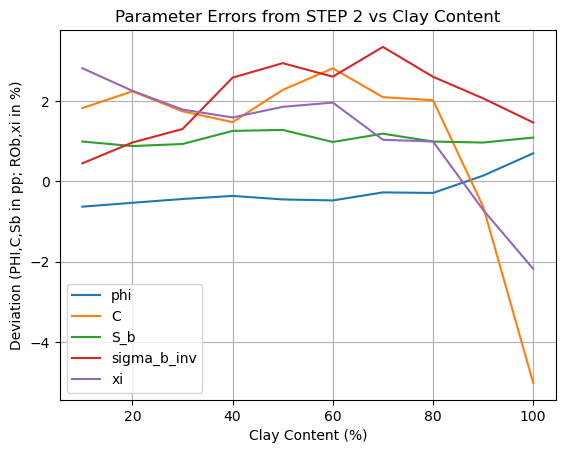

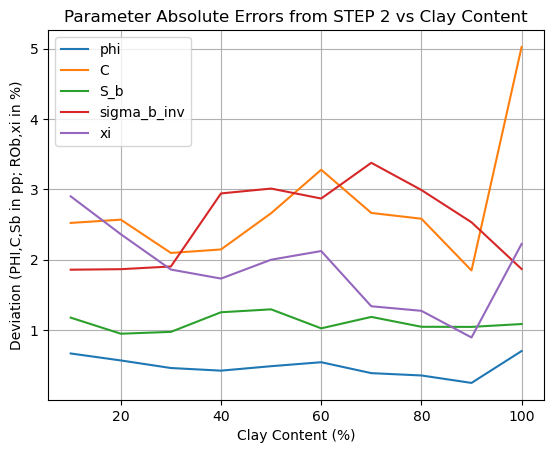

In [20]:
from dataclasses import dataclass
import numpy as np
import math
import matplotlib.pyplot as plt
from numba import njit
import os

save_dir = os.path.expanduser("~/Units/Global and Multiobjective Optimization")
os.makedirs(save_dir, exist_ok=True)

#############################################################
# 1) Fixed physical parameters
#############################################################

@dataclass
class RockFluidConstants:
    # Quartz phase
    K_q: float = 37.3e9
    mu_q: float = 44.3e9
    rho_q: float = 2600.0
    sigma_q: float = 1e-6

    # Clay phase (second solid phase)
    K_c: float = 20.9e9
    mu_c: float = 6.9e9
    rho_c: float = 2650.0
    sigma_c: float = 0.1

    # Brine phase
    K_b: float = 2.25e9
    rho_b: float = 1030.0

    # Air phase
    K_a: float = 76e3
    rho_a: float = 1.2
    sigma_a: float = 1e-4


def const_to_array(c: RockFluidConstants) -> np.ndarray:
    return np.array(
        [
            c.K_q, c.mu_q, c.rho_q, c.sigma_q,
            c.K_c, c.mu_c, c.rho_c, c.sigma_c,
            c.K_b, c.rho_b,
            c.K_a, c.rho_a, c.sigma_a
        ],
        dtype=np.float64
    )


# constants array indices
K_q, mu_q, rho_q, sigma_q = 0, 1, 2, 3
K_c, mu_c, rho_c, sigma_c = 4, 5, 6, 7
K_b, rho_b = 8, 9
K_a, rho_a, sigma_a = 10, 11, 12


#############################################################
# 2) True model
#############################################################

@dataclass
class TrueModel:
    phi_percent: float
    C_percent: float
    S_b_percent: float
    sigma_b_inv: float
    xi: float


#############################################################
# 3) Forward Modelling
#############################################################

@njit(cache=True)
def compute_AK_Amu(C_percent: float):
    A_K = 0.025 * C_percent + 2.37
    A_mu = -0.003 * C_percent + 3.14
    return A_K, A_mu


@njit(cache=True)
def forward_model(phi_percent, C_percent, S_b_percent, sigma_b_inv, xi, const):
    eps = 1e-18

    phi = phi_percent / 100.0
    C = C_percent / 100.0
    S_b = S_b_percent / 100.0

    if abs(sigma_b_inv) < eps:
        return np.nan, np.nan, np.nan
    sigma_b = 1.0 / sigma_b_inv

    rho_s = (1.0 - C) * const[rho_q] + C * const[rho_c]
    rho_f = (1.0 - S_b) * const[rho_a] + S_b * const[rho_b]
    rho_bulk = (1.0 - phi) * rho_s + phi * rho_f
    if rho_bulk <= 0.0 or (not np.isfinite(rho_bulk)):
        return np.nan, np.nan, np.nan

    beta_q = 1.0 - C
    beta_c = C

    K_V = beta_q * const[K_q] + beta_c * const[K_c]
    mu_V = beta_q * const[mu_q] + beta_c * const[mu_c]
    if abs(K_V) < eps or abs(mu_V) < eps:
        return np.nan, np.nan, np.nan

    if const[K_q] >= const[K_c]:
        K_max = const[K_q]; K_min = const[K_c]
    else:
        K_max = const[K_c]; K_min = const[K_q]

    if const[mu_q] >= const[mu_c]:
        mu_max = const[mu_q]; mu_min = const[mu_c]
    else:
        mu_max = const[mu_c]; mu_min = const[mu_q]

    dK = const[K_c] - const[K_q]
    dmu = const[mu_c] - const[mu_q]
    if abs(dK) < eps or abs(dmu) < eps:
        return np.nan, np.nan, np.nan

    denom_plus = (1.0 / dK) + beta_q / (const[K_q] + (4.0 / 3.0) * mu_max)
    denom_minus = (1.0 / dK) + beta_q / (const[K_q] + (4.0 / 3.0) * mu_min)
    if abs(denom_plus) < eps or abs(denom_minus) < eps:
        return np.nan, np.nan, np.nan

    K_HS_plus = const[K_q] + (1.0 - beta_q) / denom_plus
    K_HS_minus = const[K_q] + (1.0 - beta_q) / denom_minus
    K_HS = 0.5 * (K_HS_plus + K_HS_minus)

    denom_hq = (K_max + 2.0 * mu_max)
    denom_hc = (K_min + 2.0 * mu_min)
    if abs(denom_hq) < eps or abs(denom_hc) < eps:
        return np.nan, np.nan, np.nan

    hs_shear_q = const[mu_q] + (mu_max / 6.0) * ((9.0 * K_max + 8.0 * mu_max) / denom_hq)
    hs_shear_c = const[mu_q] + (mu_min / 6.0) * ((9.0 * K_min + 8.0 * mu_min) / denom_hc)

    denom_mu_plus = (1.0 / dmu) + beta_q / hs_shear_q
    denom_mu_minus = (1.0 / dmu) + beta_q / hs_shear_c
    if abs(denom_mu_plus) < eps or abs(denom_mu_minus) < eps:
        return np.nan, np.nan, np.nan

    mu_HS_plus = const[mu_q] + (1.0 - beta_q) / denom_mu_plus
    mu_HS_minus = const[mu_q] + (1.0 - beta_q) / denom_mu_minus
    mu_HS = 0.5 * (mu_HS_plus + mu_HS_minus)

    A_K, A_mu = compute_AK_Amu(C_percent)

    denom = 1.0 - phi
    if denom <= 1e-15:
        return np.nan, np.nan, np.nan

    exponent_bulk = A_K / denom
    exponent_shear = xi * A_mu / denom

    one_minus_phi = 1.0 - phi
    bulk_factor = one_minus_phi ** exponent_bulk
    shear_factor = one_minus_phi ** exponent_shear

    K_m_q = (K_HS / K_V) * beta_q * const[K_q] * bulk_factor
    K_m_c = (K_HS / K_V) * beta_c * const[K_c] * bulk_factor
    K_m = K_m_q + K_m_c

    mu_m_q = (mu_HS / mu_V) * beta_q * const[mu_q] * shear_factor
    mu_m_c = (mu_HS / mu_V) * beta_c * const[mu_c] * shear_factor
    mu_m = mu_m_q + mu_m_c

    denom_Kf = (1.0 - S_b) / const[K_a] + S_b / const[K_b]
    if abs(denom_Kf) < eps:
        return np.nan, np.nan, np.nan
    K_f = 1.0 / denom_Kf

    alpha_q = beta_q - K_m_q / const[K_q]
    alpha_c = beta_c - K_m_c / const[K_c]

    phi_q_prime = alpha_q - beta_q * phi
    phi_c_prime = alpha_c - beta_c * phi

    M_inv = (phi_q_prime / const[K_q]) + (phi_c_prime / const[K_c]) + (phi / K_f)
    if (not np.isfinite(M_inv)) or abs(M_inv) < 1e-18:
        return np.nan, np.nan, np.nan

    M = 1.0 / M_inv
    K_G = K_m + (alpha_q + alpha_c) ** 2 * M
    mu_G = mu_m

    Vp = math.sqrt((K_G + (4.0 / 3.0) * mu_G) / rho_bulk)
    Vs = math.sqrt(mu_G / rho_bulk)

    gamma = 0.5
    term_sigma = (
        (1.0 - phi) * (1.0 - C) * (const[sigma_q] ** gamma) +
        (1.0 - phi) * C * (const[sigma_c] ** gamma) +
        phi * S_b * (sigma_b ** gamma) +
        phi * (1.0 - S_b) * (const[sigma_a] ** gamma)
    )

    if (not np.isfinite(term_sigma)) or term_sigma <= 0.0:
        return np.nan, np.nan, np.nan

    sigma_bulk = term_sigma ** (1.0 / gamma)
    return Vp, Vs, sigma_bulk



#############################################################
# MISFIT
#############################################################

@njit(cache=True)
def objective(x, Vp_T, Vs_T, sigma_T, const, W1, W2):
    if (not np.isfinite(Vp_T)) or (not np.isfinite(Vs_T)) or (not np.isfinite(sigma_T)) or sigma_T <= 0.0:
        return 1e300

    Vp, Vs, sigma = forward_model(x[0], x[1], x[2], x[3], x[4], const)

    if (not np.isfinite(Vp)) or (not np.isfinite(Vs)) or (not np.isfinite(sigma)) or sigma <= 0.0:
        return 1e300

    return (
        abs(Vp - Vp_T)
        + W1 * abs(Vs - Vs_T)
        + W2 * abs((1.0 / sigma) - (1.0 / sigma_T))
    )


#############################################################
# PSO in normalized space y ∈ [0,1]^5
#############################################################

@njit(cache=True)
def randn_box_muller():
    u1 = np.random.random()
    u2 = np.random.random()
    if u1 < 1e-16:
        u1 = 1e-16
    return math.sqrt(-2.0 * math.log(u1)) * math.cos(2.0 * math.pi * u2)


@njit(cache=True)
def clamp_velocity_component(v, vmax, vmin):
    av = abs(v)
    if av > vmax:
        return math.copysign(vmax, v)
    if vmin > 0.0 and av < vmin and av > 0.0:
        return math.copysign(vmin, v)
    return v


@njit(cache=True)
def reflect_01(y, v):
    while y < 0.0 or y > 1.0:
        if y < 0.0:
            y = -y
            v = -v
        elif y > 1.0:
            y = 2.0 - y
            v = -v
    if y < 0.0:
        y = 0.0
    elif y > 1.0:
        y = 1.0
    return y, v


@njit(cache=True)
def map_y_to_x(y, lo, hi, x_out):
    for j in range(5):
        x_out[j] = lo[j] + y[j] * (hi[j] - lo[j])


@njit(cache=True)
def outside_01(y_row):
    for j in range(5):
        if y_row[j] < 0.0 or y_row[j] > 1.0:
            return True
    return False


# ============================================================
# init_mode:
# PSO
#   - if init_mode is 0 the cloud is generated with uniform distribution ont the search space
#   - if init_mode is 1 the cloud is generated with gaussian distribution around the midpoit
# ============================================================

@njit(cache=True)
def pso_single_norm(
    Vp_T, Vs_T, sigma_T,
    const,
    lo, hi,
    n_particles,
    n_iters,
    W1, W2,
    tol,
    w_start, w_end,
    c_soc, c_cog,
    vmax_abs, vmin_abs,
    seed,
    init_mode,      # 0=uniform init, 1=center 
    init_sigma_y,   # std dev in normalized space around center (only if init_mode=1)
    zero_vel,
    eps_improve,
    patience
):
    np.random.seed(seed)

    dim = 5
    Xtmp = np.empty(dim, dtype=np.float64)

    Y = np.empty((n_particles, dim), dtype=np.float64)
    V = np.empty((n_particles, dim), dtype=np.float64)

    PbestY = np.empty((n_particles, dim), dtype=np.float64)
    Fpbest = np.empty(n_particles, dtype=np.float64)

    # ---------------------------------------
    # Initialization (midpoint of bounds)
    # ---------------------------------------
    center = 0.5


    for i in range(n_particles):
        for j in range(dim):
            if init_mode == 1:
                # one particle exactly at the center, others around the center
                if i == 0:
                    y = center
                else:
                    y = center + init_sigma_y * randn_box_muller()
                    # keep y inside [0,1] using reflection 
                    y, _ = reflect_01(y, 0.0)
            else:
                # uniform in [0,1]
                y = np.random.random()

            Y[i, j] = y

            if zero_vel == 1:
                V[i, j] = 0.0
            else:
                V[i, j] = (2.0 * np.random.random() - 1.0) * vmax_abs

        Fpbest[i] = 1e300

    # -----------------------------
    # Initial evaluation
    # -----------------------------
    gbestY = np.empty(dim, dtype=np.float64)
    f_gbest = 1e300

    for i in range(n_particles):
        if outside_01(Y[i]):
            f = 1e300
        else:
            map_y_to_x(Y[i], lo, hi, Xtmp)
            f = objective(Xtmp, Vp_T, Vs_T, sigma_T, const, W1, W2)

        Fpbest[i] = f
        for j in range(dim):
            PbestY[i, j] = Y[i, j]

        if f < f_gbest:
            f_gbest = f
            for j in range(dim):
                gbestY[j] = Y[i, j]

    stop_reason = 0  # 0=none, 1=tol, 2=patience, 3=max_iters
    stop_iter = 0

    if f_gbest <= tol:
        stop_reason = 1
        stop_iter = 0
        map_y_to_x(gbestY, lo, hi, Xtmp)
        return Xtmp.copy(), f_gbest, stop_iter, stop_reason

    best_seen = f_gbest
    no_improve = 0

    # -----------------------------
    # Main PSO loop
    # -----------------------------
    for it in range(1, n_iters + 1):
        t = (it - 1) / max(1, (n_iters - 1))
        w = w_start + (w_end - w_start) * t

        for i in range(n_particles):
            for j in range(dim):
                r1 = np.random.random()
                r2 = np.random.random()

                v_new = (
                    w * V[i, j]
                    + c_soc * r1 * (gbestY[j] - Y[i, j])
                    + c_cog * r2 * (PbestY[i, j] - Y[i, j])
                )
                v_new = clamp_velocity_component(v_new, vmax_abs, vmin_abs)

                y_new = Y[i, j] + v_new
                y_new, v_new = reflect_01(y_new, v_new)

                Y[i, j] = y_new
                V[i, j] = v_new

            if outside_01(Y[i]):
                f = 1e300
            else:
                map_y_to_x(Y[i], lo, hi, Xtmp)
                f = objective(Xtmp, Vp_T, Vs_T, sigma_T, const, W1, W2)

            if f < Fpbest[i]:
                Fpbest[i] = f
                for j in range(dim):
                    PbestY[i, j] = Y[i, j]

                if f < f_gbest:
                    f_gbest = f
                    for j in range(dim):
                        gbestY[j] = Y[i, j]

        if f_gbest <= tol:
            stop_reason = 1
            stop_iter = it
            break

        thr = eps_improve * max(1.0, best_seen)
        if best_seen - f_gbest > thr:
            best_seen = f_gbest
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                stop_reason = 2
                stop_iter = it
                break

    if stop_reason == 0:
        stop_reason = 3
        stop_iter = n_iters

    map_y_to_x(gbestY, lo, hi, Xtmp)
    return Xtmp.copy(), f_gbest, stop_iter, stop_reason


#############################################################
# Utilities
#############################################################

def add_relative_noise(rng: np.random.Generator, x: float, rel_std: float = 0.01) -> float:
    return x * (1.0 + rng.normal(0.0, rel_std))

def dev_points(out_percent: float, inp_percent: float) -> float:
    return out_percent - inp_percent

def dev_rel_percent(out: float, inp: float) -> float:
    eps = 1e-18
    denom = inp if abs(inp) > eps else eps
    return 100.0 * (out - inp) / denom


#############################################################
# MAIN
#############################################################

if __name__ == "__main__":
    W1 = 1.0
    W2 = 100.0
    tol2 = 1e-9

    reason_map = {0: "none", 1: "tol", 2: "patience", 3: "max_iters"}

    lo = np.array([0.0,   0.0,  80.0,  0.2, 2.5], dtype=np.float64)
    hi = np.array([70.0, 100.0, 100.0, 25.0, 2.9], dtype=np.float64)


    const = const_to_array(RockFluidConstants())

    c_soc2 = 1.49445
    c_cog2 = 1.49445

    w_start2 = 0.2
    w_end2   = 0.02

    vmax_abs_phase2 = 0.02
    vmin_abs = 0.0

    N_PART_PHASE2 = 1996
    N_ITERS_PHASE2 = 500

    INIT_MODE_PHASE2 = 1
    INIT_SIGMA_Y_PHASE2 = 0.02

    ZERO_VEL_PHASE2 = 0

    EPS_IMPROVE = 1e-6
    PATIENCE2 = 100


    base_seed_noise = 369
    base_seed_inversion = 246
    rng = np.random.default_rng(seed=base_seed_noise)


    #Error Matrices initialisation
    n_p = 10
    n_k = 10
    n_s = 10 
    
    err_phi3   = np.zeros((n_p, n_k, n_s), dtype=np.float64)
    err_C3     = np.zeros((n_p, n_k, n_s), dtype=np.float64)
    err_Sb3    = np.zeros((n_p, n_k, n_s), dtype=np.float64)
    err_rhob3  = np.zeros((n_p, n_k, n_s), dtype=np.float64)
    err_xi3    = np.zeros((n_p, n_k, n_s), dtype=np.float64)

    aerr_phi3  = np.zeros((n_p, n_k, n_s), dtype=np.float64)
    aerr_C3    = np.zeros((n_p, n_k, n_s), dtype=np.float64)
    aerr_Sb3   = np.zeros((n_p, n_k, n_s), dtype=np.float64)
    aerr_rhob3 = np.zeros((n_p, n_k, n_s), dtype=np.float64)
    aerr_xi3   = np.zeros((n_p, n_k, n_s), dtype=np.float64)

   
    C_content3 = np.zeros((n_p, n_k), dtype=np.float64)

    

    # warm-up compilation
    safe_x = np.array([41.0, 20.0, 90.0, 0.5, 2.7], dtype=np.float64)
    Vp_s, Vs_s, sig_s = forward_model(safe_x[0], safe_x[1], safe_x[2], safe_x[3], safe_x[4], const)
    _ = objective(safe_x, float(Vp_s), float(Vs_s), float(sig_s), const, W1, W2)


    _ = pso_single_norm(
        float(Vp_s), float(Vs_s), float(sig_s),
        const, lo, hi,
        8, 5, W1, W2, tol2,
        w_start2, w_end2, c_soc2, c_cog2,
        0.02, 0.0,
        493,
        1, 0.02, 1,
        1e-12, 5
    )

    # ==========================================================     
    # j = Start of the Inversion    
    # ==========================================================

    
    for p in range(n_p):
        seed_noise = 369 + p
        rng = np.random.default_rng(seed=seed_noise)

        for j, k in enumerate(range(0, 100, 10)):
            print("\n" + "=" * 70)
            print(f"RUN p = {p}, k = {k}")
            print("=" * 70)

            true_model = TrueModel(
                phi_percent=41.0,
                C_percent=10.0 + k,
                S_b_percent=90.0,
                sigma_b_inv=0.5,
                xi=2.7
            )

            #C_content3.append(true_model.C_percent)

            Vp_true, Vs_true, sigma_true = forward_model(
                true_model.phi_percent, true_model.C_percent, true_model.S_b_percent,
                true_model.sigma_b_inv, true_model.xi, const
            )

            Vp_obs = add_relative_noise(rng, float(Vp_true), 0.01)
            Vs_obs = add_relative_noise(rng, float(Vs_true), 0.01)
            sigma_obs = add_relative_noise(rng, float(sigma_true), 0.01)

            print("TRUE:")
            print(f"  Vp_true    = {Vp_true:.6g} m/s")
            print(f"  Vs_true    = {Vs_true:.6g} m/s")
            print(f"  sigma_true = {sigma_true:.6g} S/m")

            print("\nOBS (1% noise):")
            print(f"  Vp_obs     = {Vp_obs:.6g} m/s")
            print(f"  Vs_obs     = {Vs_obs:.6g} m/s")
            print(f"  sigma_obs  = {sigma_obs:.6g} S/m")

            for s in range(n_s):
                seed_run = base_seed_inversion + s
                print(seed_run)


                # PSO
                best2, f2, it2, reason2 = pso_single_norm(
                    Vp_obs, Vs_obs, sigma_obs,
                    const, lo, hi,
                    N_PART_PHASE2, N_ITERS_PHASE2,
                    W1, W2, tol2,
                    w_start2, w_end2, c_soc2, c_cog2,
                    vmax_abs_phase2, vmin_abs,
                    seed_run,
                    INIT_MODE_PHASE2, INIT_SIGMA_Y_PHASE2, ZERO_VEL_PHASE2,
                    EPS_IMPROVE, PATIENCE2
                )

                print("\n=== PSO (xi in [2.5, 2.9], midpoint restart) ===")
                print(f"Best objective f = {f2:.6e}")
                print(f"Stopped at iter = {it2} (reason={reason_map.get(reason2,'?')})")
                print(f"  phi_percent   = {best2[0]:.6f}")
                print(f"  C_percent     = {best2[1]:.6f}")
                print(f"  S_b_percent   = {best2[2]:.6f}")
                print(f"  sigma_b_inv   = {best2[3]:.6f}")
                print(f"  xi            = {best2[4]:.6f}")

                # deviations
                e_phi = dev_points(best2[0], true_model.phi_percent)
                e_C   = dev_points(best2[1], true_model.C_percent)
                e_Sb  = dev_points(best2[2], true_model.S_b_percent)
                e_rb  = dev_rel_percent(best2[3], true_model.sigma_b_inv)
                e_xi  = dev_rel_percent(best2[4], true_model.xi)

                ae_phi = abs(e_phi)
                ae_C   = abs(e_C)
                ae_Sb  = abs(e_Sb)
                ae_rb  = abs(e_rb)
                ae_xi  = abs(e_xi)

                print("\nDeviations vs true_model:")
                print(f"  devPHI (pp)   = {e_phi:.4f}")
                print(f"  devCC  (pp)   = {e_C:.4f}")
                print(f"  devSB  (pp)   = {e_Sb:.4f}")
                print(f"  devROb (%)    = {e_rb:.4f}")
                print(f"  devfac (%)    = {e_xi:.4f}")

                print("\nAbsolute deviations:")
                print(f"  |devPHI| (pp) = {ae_phi:.4f}")
                print(f"  |devCC|  (pp) = {ae_C:.4f}")
                print(f"  |devSB|  (pp) = {ae_Sb:.4f}")
                print(f"  |devROb| (%)  = {ae_rb:.4f}")
                print(f"  |devfac| (%)  = {ae_xi:.4f}")

            
                # save into 3D arrays [p, j, s]
                err_phi3[p, j, s]   = e_phi
                err_C3[p, j, s]     = e_C
                err_Sb3[p, j, s]    = e_Sb
                err_rhob3[p, j, s]  = e_rb
                err_xi3[p, j, s]    = e_xi

                aerr_phi3[p, j, s]  = ae_phi
                aerr_C3[p, j, s]    = ae_C
                aerr_Sb3[p, j, s]   = ae_Sb
                aerr_rhob3[p, j, s] = ae_rb
                aerr_xi3[p, j, s]   = ae_xi

                C_content3[p, j] = true_model.C_percent


    matrices = {
        "err_phi3": err_phi3,
        "err_C3": err_C3,
        "err_Sb3": err_Sb3,
        "err_rhob3": err_rhob3,
        "err_xi3": err_xi3
    }

    abs_matrices = {
        "aerr_phi3": aerr_phi3,
        "aerr_C3": aerr_C3,
        "aerr_Sb3": aerr_Sb3,
        "aerr_rhob3": aerr_rhob3,
        "aerr_xi3": aerr_xi3
    }

    print("\n" + "=" * 100)
    print("STATISTICAL ANALYSIS IN 2 STEP")
    print("=" * 100)

    print("\n" + "=" * 50)
    print("STEP 1: GLOBAL STATISTICAL ANALYSIS")
    print("=" * 50)


    print("###########GLOBAL MAE###########")
    for name, v in abs_matrices.items():
        print(name)
        print(np.mean(v))

    print("________________________")
    print("###########GLOBAL BIAS###########")
    for name, v in matrices.items():
        print(name)
        print(np.mean(v))

    print("________________________")
    print("###########GLOBAL SIGNED STD###########")
    for name, v in matrices.items():
        print(name)
        print(np.std(v, ddof=1))

    print("________________________")
    print("###########GLOBAL RMSE###########")
    for name, v in matrices.items():
        print(name)
        print(np.sqrt(np.mean(v**2)))


    print("\n" + "=" * 50)
    print("STEP 2: STATISTICAL ANALYSIS FOR C VALUES")
    print("=" * 50)

    print("###########MAE###########")
    for name, v in abs_matrices.items():
        print(name)
        print(np.mean(v, axis=(0,2)))
        
    print("________________________")
    print("###########BIAS###########")
    for name, v in matrices.items():
        print(name)
        print(np.mean(v, axis=(0,2)))

    print("________________________")
    print("###########STD###########")
    for name, v in matrices.items():
        print(name)
        print(np.std(v, axis=(0,2), ddof=1))

    print("________________________")
    print("###########RMSE###########")
    for name, v in matrices.items():
        print(name)
        print(np.sqrt(np.mean(v**2, axis=(0,2))))



    C_content = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

    plt.figure()
    plt.plot(C_content, np.mean(err_phi3, axis=(0,2)),   label='phi')
    plt.plot(C_content, np.mean(err_C3, axis=(0,2)),     label='C')
    plt.plot(C_content, np.mean(err_Sb3, axis=(0,2)),    label='S_b')
    plt.plot(C_content, np.mean(err_rhob3, axis=(0,2)),  label='sigma_b_inv')
    plt.plot(C_content, np.mean(err_xi3, axis=(0,2)),    label='xi')
    plt.xlabel("Clay Content (%)")
    plt.ylabel("Deviation (PHI,C,Sb in pp; ROb,xi in %)")
    plt.title("Parameter Errors from STEP 2 vs Clay Content")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(C_content, np.mean(aerr_phi3, axis=(0,2)),   label='phi')
    plt.plot(C_content, np.mean(aerr_C3, axis=(0,2)),     label='C')
    plt.plot(C_content, np.mean(aerr_Sb3, axis=(0,2)),    label='S_b')
    plt.plot(C_content, np.mean(aerr_rhob3, axis=(0,2)),  label='sigma_b_inv')
    plt.plot(C_content, np.mean(aerr_xi3, axis=(0,2)),    label='xi')
    plt.xlabel("Clay Content (%)")
    plt.ylabel("Deviation (PHI,C,Sb in pp; ROb,xi in %)")
    plt.title("Parameter Absolute Errors from STEP 2 vs Clay Content")
    plt.legend()
    plt.grid(True)
    plt.show()